In [1]:
import pandas as pd
import mne
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
subject_list=['s05','s06','s07','s08','s09']
subject=subject_list[4]


In [91]:
#epochs_united.save(f'1_Epochs/{subject}_epochs-epo.fif', overwrite=True)
#np.savetxt(f'1_Epochs/{subject}_events.csv',events_united)

In [7]:
epochs=mne.read_epochs(f'../1_Epochs/{subject}_epochs-epo.fif')

Reading c:\Users\user\Desktop\MNE Playground\Gurgen's noteb00ks\..\1_Epochs\s09_epochs-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =       0.00 ...    1900.00 ms
        0 CTF compensation matrices available
Not setting metadata
151 matching events found
No baseline correction applied
0 projection items activated


In [8]:
freqs = np.linspace(0.1, 100, 50)   # frequencies of interest
n_cycles = freqs / 2. 
freqs

array([  0.1       ,   2.13877551,   4.17755102,   6.21632653,
         8.25510204,  10.29387755,  12.33265306,  14.37142857,
        16.41020408,  18.44897959,  20.4877551 ,  22.52653061,
        24.56530612,  26.60408163,  28.64285714,  30.68163265,
        32.72040816,  34.75918367,  36.79795918,  38.83673469,
        40.8755102 ,  42.91428571,  44.95306122,  46.99183673,
        49.03061224,  51.06938776,  53.10816327,  55.14693878,
        57.18571429,  59.2244898 ,  61.26326531,  63.30204082,
        65.34081633,  67.37959184,  69.41836735,  71.45714286,
        73.49591837,  75.53469388,  77.57346939,  79.6122449 ,
        81.65102041,  83.68979592,  85.72857143,  87.76734694,
        89.80612245,  91.84489796,  93.88367347,  95.92244898,
        97.96122449, 100.        ])

In [ ]:
power = mne.time_frequency.tfr_morlet(
    epochs, freqs=freqs, n_cycles=n_cycles, return_itc=False, decim=2, average=False
)  # returns AverageTFR object


NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


In [10]:
power

Data type,Power Estimates
Data source,Epochs
Number of epochs,151
Dims,"epoch, channel, freq, time"
Estimation method,morlet
Number of channels,5
Number of timepoints,1901
Number of frequency bins,50
Frequency range,0.10 – 100.00 Hz


In [11]:

channels = epochs.ch_names[0:4]  # choose subset of channels to keep plot small
states = list(epochs.event_id.keys())

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode

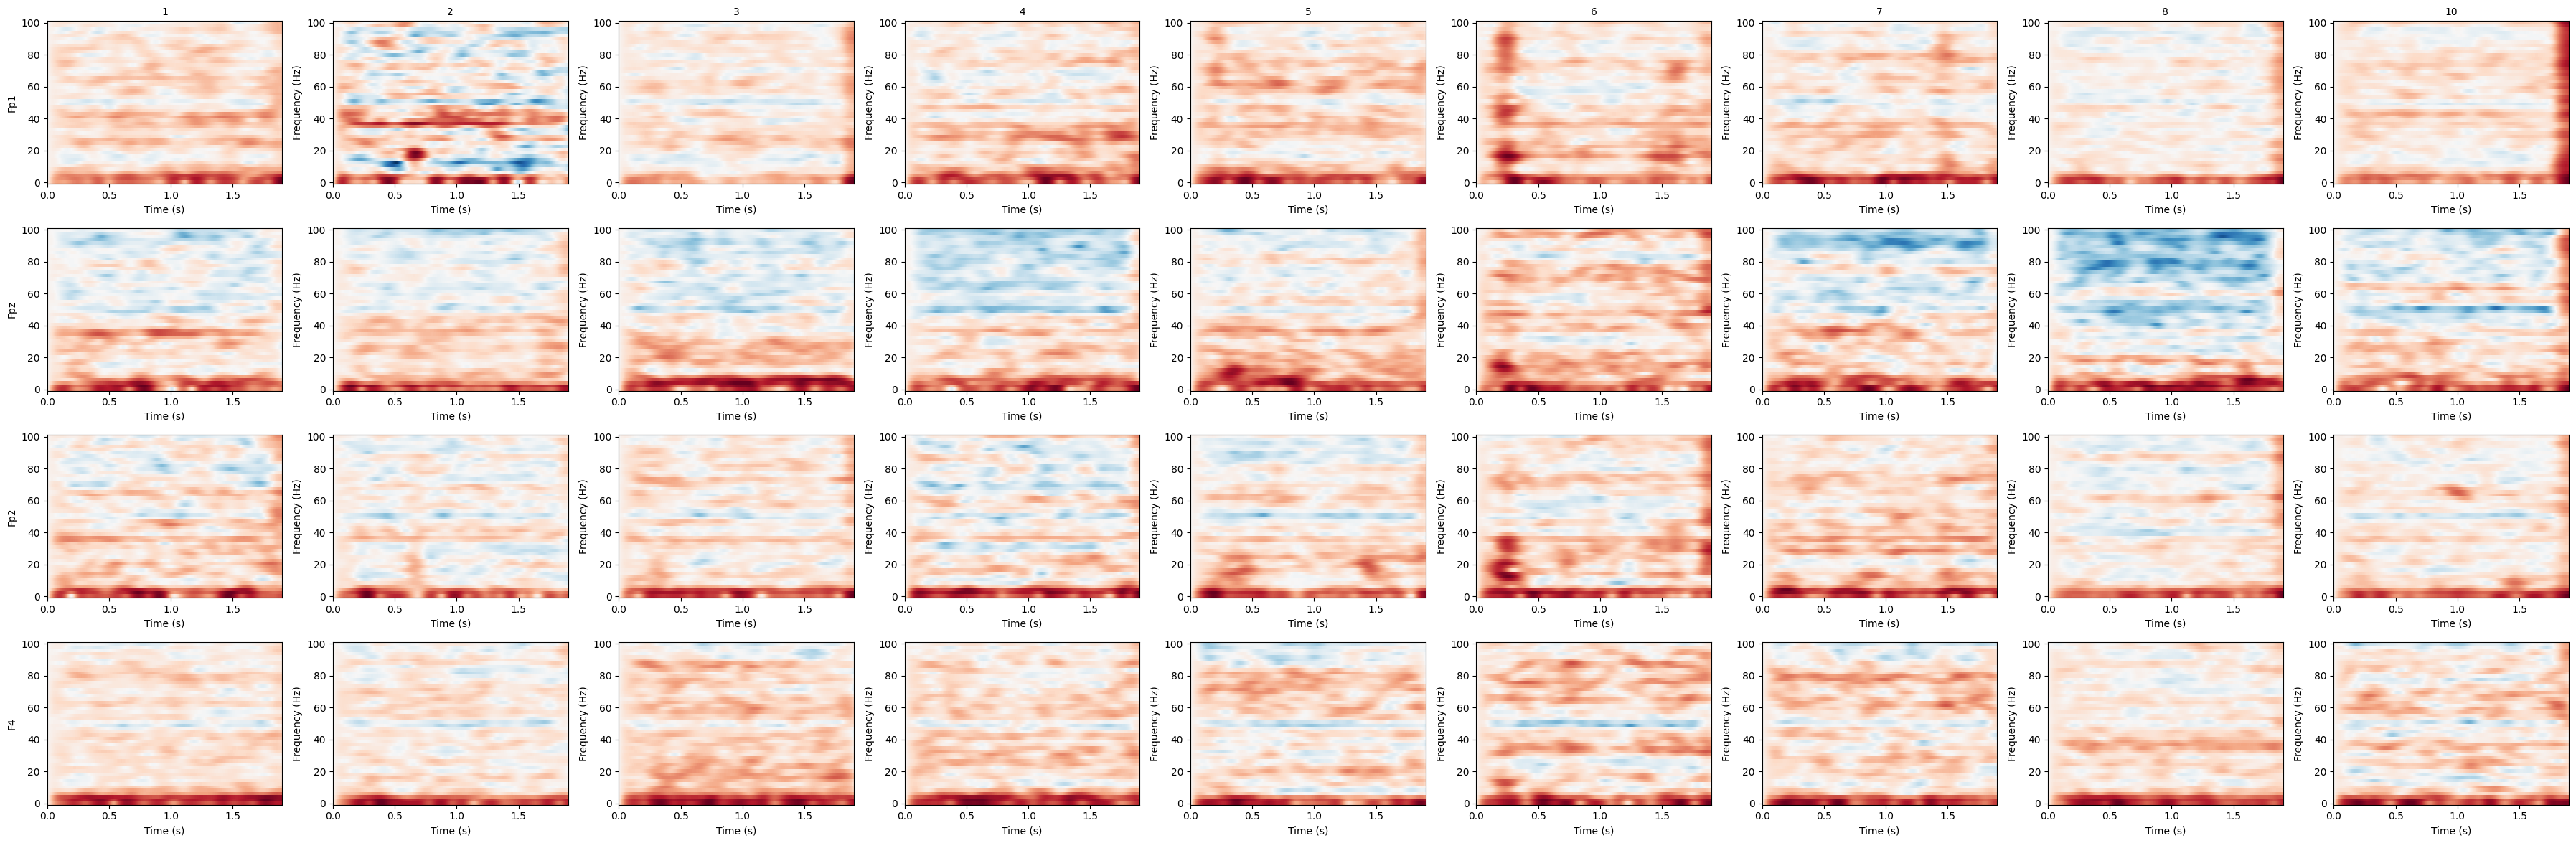

In [12]:


fig, axes = plt.subplots(len(channels), len(states),
                         figsize=(4*len(states), 3*len(channels)),
                         squeeze=False)

for i, ch in enumerate(channels):
    for j, state in enumerate(states):
        # select power for this condition
        power_cond = power[state].copy().pick(ch).average()

        # plot spectrogram into subplot
        power_cond.plot([0], baseline=(-0.3, 0), mode='logratio',
                        axes=axes[i, j], show=False, colorbar=False)

        if i == 0:
            axes[i, j].set_title(state, fontsize=10)
        if j == 0:
            axes[i, j].set_ylabel(ch)

plt.tight_layout()
plt.show()

In [13]:
epochs.event_id

{'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '10': 10}

In [15]:
out_dir = Path("2_TFR")
out_dir.mkdir(parents=True, exist_ok=True)  # создаём, если нет

power.save(f'../2_TFR/{subject}_tfr-tfr.h5')

In [16]:
subject

's09'

In [17]:
power.shape

(151, 5, 50, 1901)